# KBO 3개년 관중 수 예측 통합 EDA 분석 및 모델링

이 노트북은 KBO 2023-2025년 관중 및 날씨 데이터를 분석하여 숨겨진 흥행 패턴을 찾아내고, 2025년 하반기 관중 수를 하이브리드 모델로 예측합니다.

In [1]:
from korean_font import set_korean_font
set_korean_font()

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


## 1. 데이터 전처리 및 Feature Engineering

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
kbo_df = pd.read_csv('KBO_2023_2025_FINAL_MASTER_2160.csv', encoding='utf-8-sig')
weather_df = pd.read_csv('KBO_Weather_Combined_2023_2025.csv', encoding='utf-8-sig')

# 컬럼 정리
kbo_df.columns = kbo_df.columns.str.strip()
weather_df = weather_df.rename(columns={'일시': '날짜'})
weather_df.columns = weather_df.columns.str.strip()

# 병합
df = pd.merge(kbo_df, weather_df, on=['지점', '날짜'], how='left')

# 2. 구장 정제
df.loc[(df['홈'] == 'NC') & (df['구장'] == '사직'), '구장'] = '창원'

main_stadiums = ['고척', '잠실', '수원', '광주', '문학', '대구', '창원', '사직', '한밭', '대전']
df['구장'] = df['구장'].replace({'한밭': '대전'})

# 2구장 여부 (삭제 대신 정보 유지)
df['보조구장'] = (~df['구장'].isin(main_stadiums)).astype(int)

# 3. 시간 변수
df['datetime'] = pd.to_datetime(df['날짜'].astype(str) + ' ' + df['경기_시간'].astype(str))
df = df.sort_values('datetime').reset_index(drop=True)

df['연도'] = df['datetime'].dt.year
df['월'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['주말'] = df['weekday'].isin([5, 6]).astype(int)

# 4. 수용인원
def map_capacity(row):
    stadium = row['구장']
    year = row['연도']
    cap = {'고척': 16000, '잠실': 23750, '수원': 18700, '광주': 20500,
           '문학': 23000, '대구': 24000, '창원': 17891}
    
    if stadium in cap:
        return cap[stadium]
    if stadium == '사직':
        return 22990 if year == 2023 else (22758 if year == 2024 else 22669)
    if stadium == '대전':
        return 12000 if year <= 2024 else 17000
    return np.nan

df['Capacity'] = df.apply(map_capacity, axis=1)
df['Actual_Attendance'] = df['관중수']

# ⭐ 점유율 (핵심 변수)
df['점유율'] = df['Actual_Attendance'] / df['Capacity']

# 5. 날씨 변수
T = df['평균기온(°C)']
RH = df['평균 상대습도(%)'].fillna(df['평균 상대습도(%)'].mean())

df['불쾌지수'] = (9/5 * T) - 0.55 * (1 - RH/100) * (9/5 * T - 26) + 32

# 6. 팀 성적 (Leakage 방지)
df['홈_승리_point'] = np.where(
    df['홈_점수'] > df['방문_점수'], 1.0,
    np.where(df['홈_점수'] == df['방문_점수'], 0.5, 0.0)
)

df['홈_최근10경기승률'] = df.groupby(['연도', '홈'])['홈_승리_point'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
).fillna(0.5)

# 시즌 진행률
df['시즌진행_경기수'] = df.groupby(['연도', '홈']).cumcount() + 1
df['시즌_진행률'] = df['시즌진행_경기수'] / 72.0

# 7. 휴일 변수 (주말 분리)
holidays_full = [
    '2023-01-01','2023-01-21','2023-01-22','2023-01-23','2023-01-24','2023-03-01',
    '2023-05-01','2023-05-05','2023-05-27','2023-05-29','2023-06-06','2023-08-15',
    '2023-09-28','2023-09-29','2023-09-30','2023-10-02','2023-10-03','2023-10-09','2023-12-25',
    
    '2024-01-01','2024-02-09','2024-02-10','2024-02-11','2024-02-12','2024-03-01',
    '2024-04-10','2024-05-01','2024-05-05','2024-05-06','2024-05-15','2024-06-06',
    '2024-08-15','2024-09-16','2024-09-17','2024-09-18','2024-10-01','2024-10-03',
    '2024-10-09','2024-12-25',
    
    '2025-01-01','2025-01-28','2025-01-29','2025-01-30','2025-03-01','2025-03-03',
    '2025-05-01','2025-05-05','2025-05-06','2025-06-06','2025-08-15',
    '2025-10-03','2025-10-05','2025-10-06','2025-10-07','2025-10-08',
    '2025-10-09','2025-12-25'
]

df['is_holiday'] = df['날짜'].astype(str).isin(holidays_full).astype(int)

# 8. 인기도 (Leakage 제거 버전 ⭐)
df['홈팀_인기도'] = df.groupby('홈')['관중수'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df['원정팀_인기도'] = df.groupby('방문')['관중수'].transform(
    lambda x: x.shift(1).expanding().mean()
)

# 초기값 보정
df['홈팀_인기도'] = df['홈팀_인기도'].fillna(df['관중수'].mean())
df['원정팀_인기도'] = df['원정팀_인기도'].fillna(df['관중수'].mean())

# 9. 라이벌 매치
# 수정된 라이벌 및 주요 매치업 리스트
rivals = [
    ('LG', '두산'), ('두산', 'LG'),       # 잠실 라이벌
    ('LG', '롯데'), ('롯데', 'LG'),       # 엘꼴라시코
    ('삼성', '롯데'), ('롯데', '삼성'),    # 82 클래식
    ('KIA', '한화'), ('한화', 'KIA'),      # 금강대교 시리즈 (현재 포함됨)
    
    # 시각화 자료 기반 추가 추천
    ('LG', 'KIA'), ('KIA', 'LG'),         # 최고 점유율 매치업
    ('LG', '한화'), ('한화', 'LG'),       # 고점유율 매치업
    ('두산', 'KIA'), ('KIA', '두산')       # 고점유율 매치업
]

df['라이벌매치'] = df.apply(lambda row: int((row['홈'], row['방문']) in rivals), axis=1)

# 10. 데이터 분할
train_df = df[(df['datetime'] >= '2023-04-01') & (df['datetime'] <= '2025-07-31 23:59:59')].copy()
test_df = df[(df['datetime'] >= '2025-08-01') & (df['datetime'] <= '2025-10-31 23:59:59')].copy()

print(f"최종 데이터: {len(df)}")
print(f"학습 데이터: {len(train_df)} / 테스트 데이터: {len(test_df)}")

최종 데이터: 2160
학습 데이터: 1935 / 테스트 데이터: 225


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# Seaborn 먼저 설정
sns.set_theme(style="whitegrid")

# ⭐ 한글 폰트 설정 (OS별)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (Colab 포함)
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 2. 상세 EDA 분석

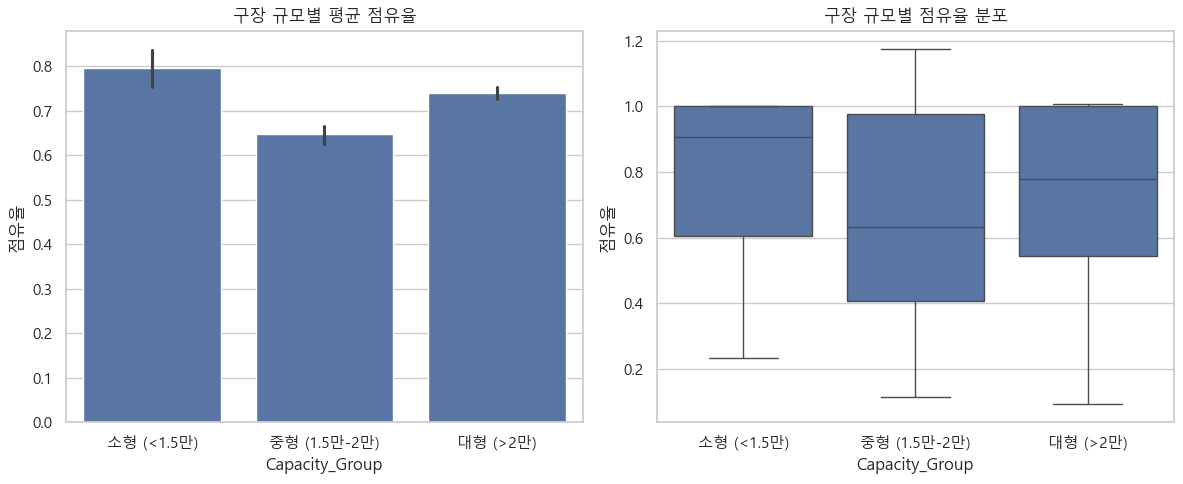

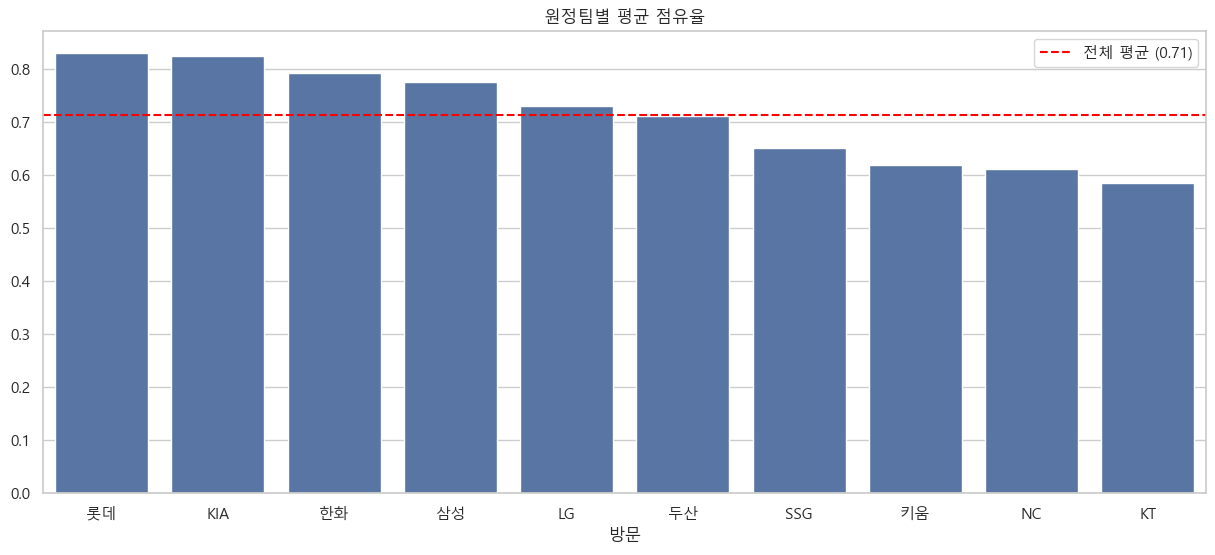

원정팀 방문 시 점유율 증가율 (%):
방문
롯데     16.340335
KIA    15.565885
한화     11.104178
삼성      8.613850
LG      2.349015
두산     -0.130491
SSG    -8.763296
키움    -13.300475
NC    -14.178147
KT    -17.903334
Name: 점유율, dtype: float64


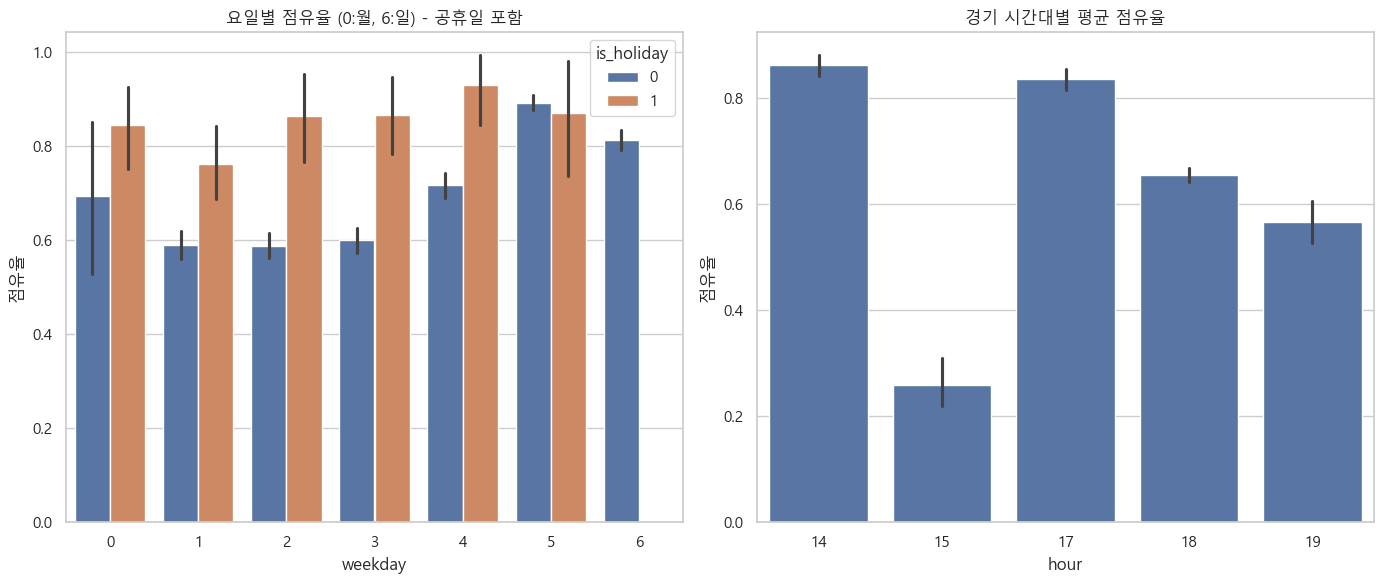

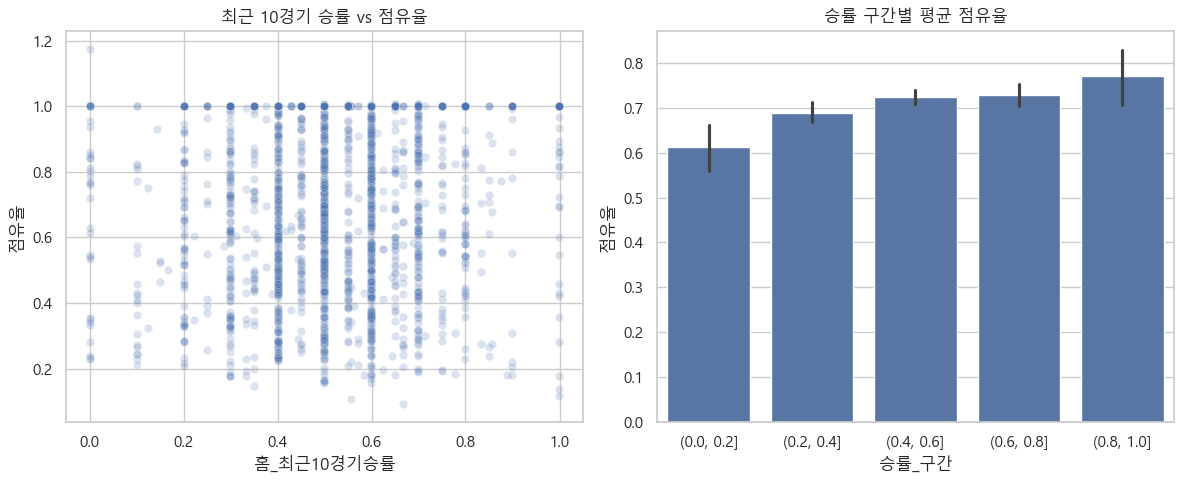

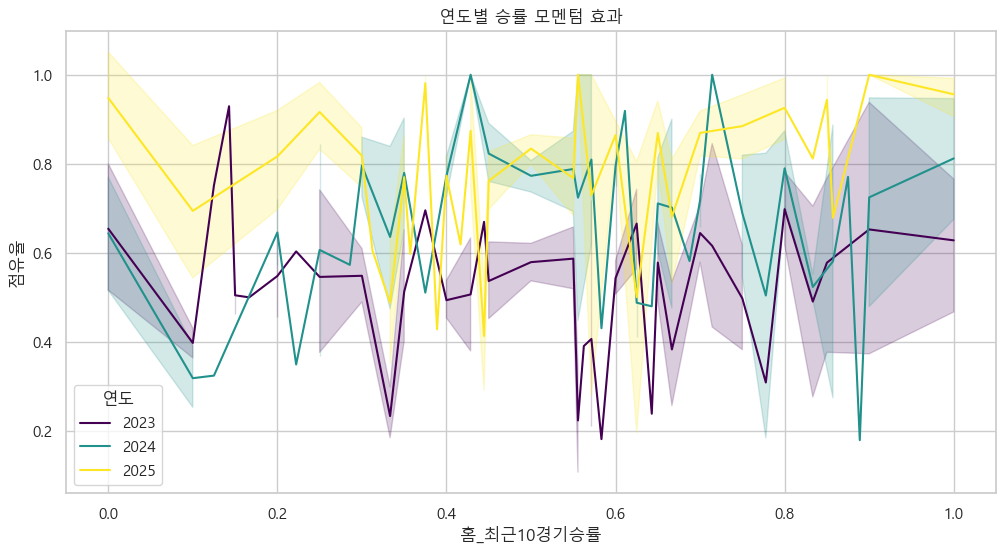

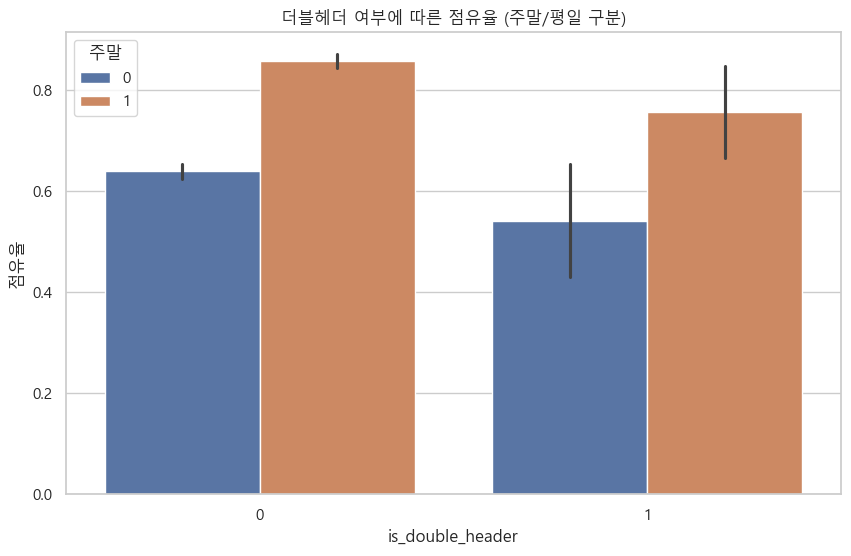

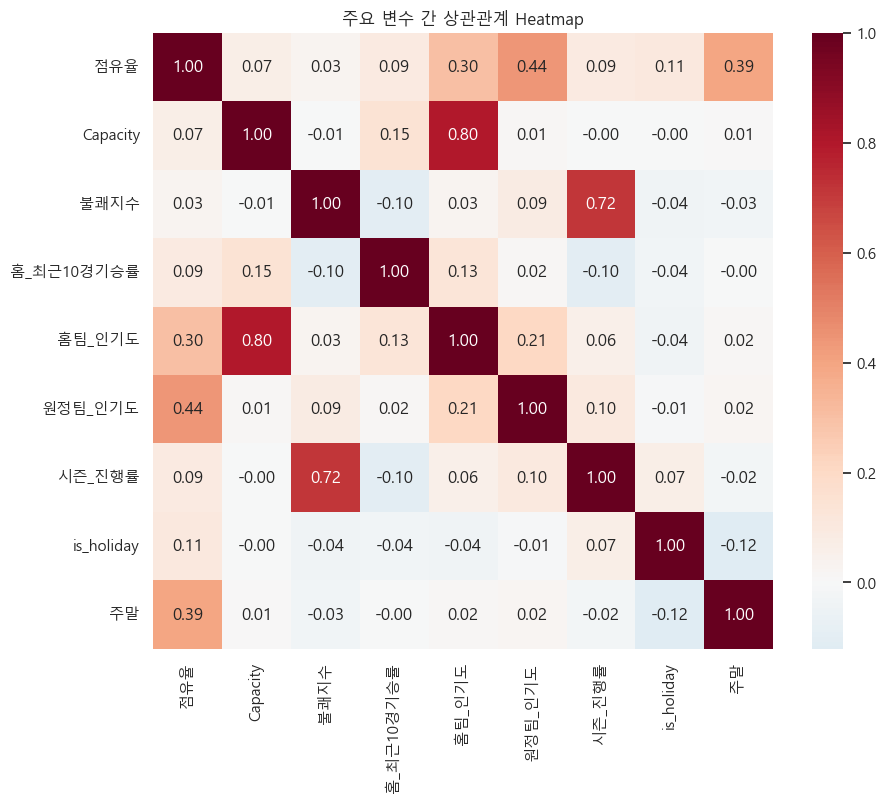

C:\Users\subin\AppData\Local\Temp\ipykernel_21108\4048879346.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gocheok_df, x='월', y='점유율', palette='coolwarm')


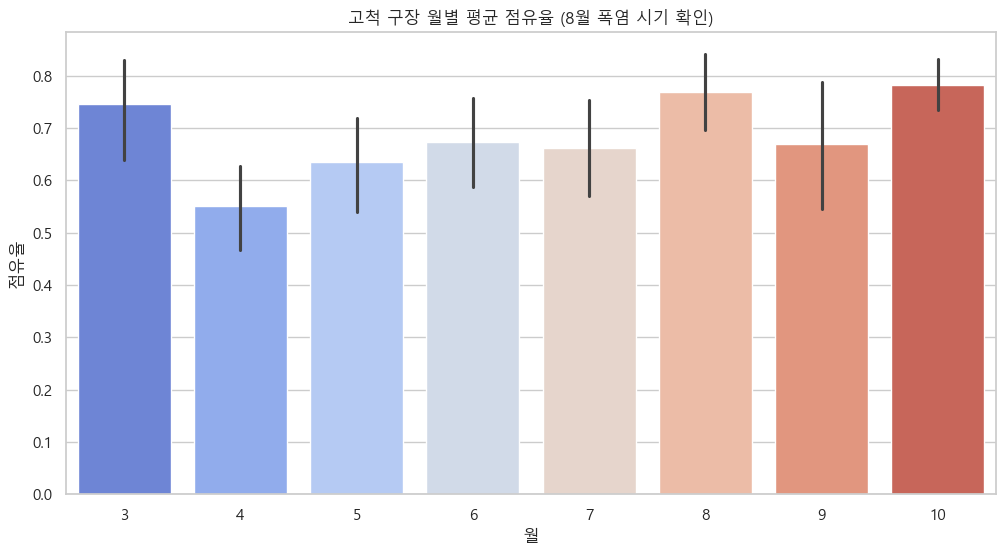

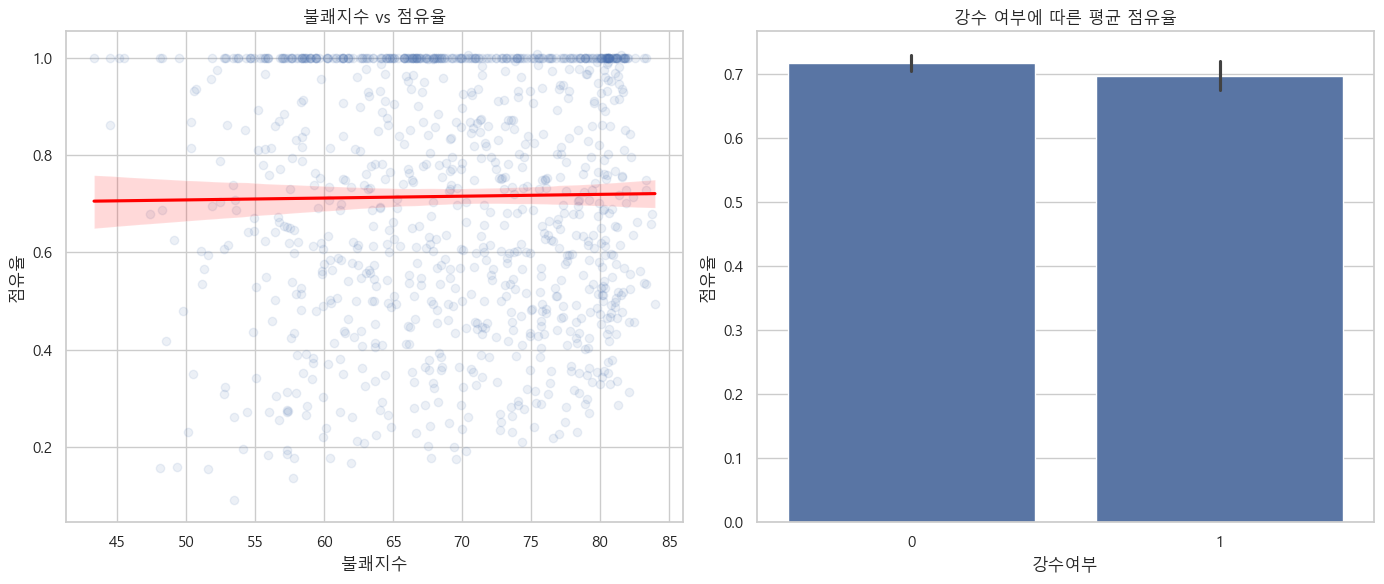

C:\Users\subin\AppData\Local\Temp\ipykernel_21108\4048879346.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_matchups.values, y=top_matchups.index, palette='magma')


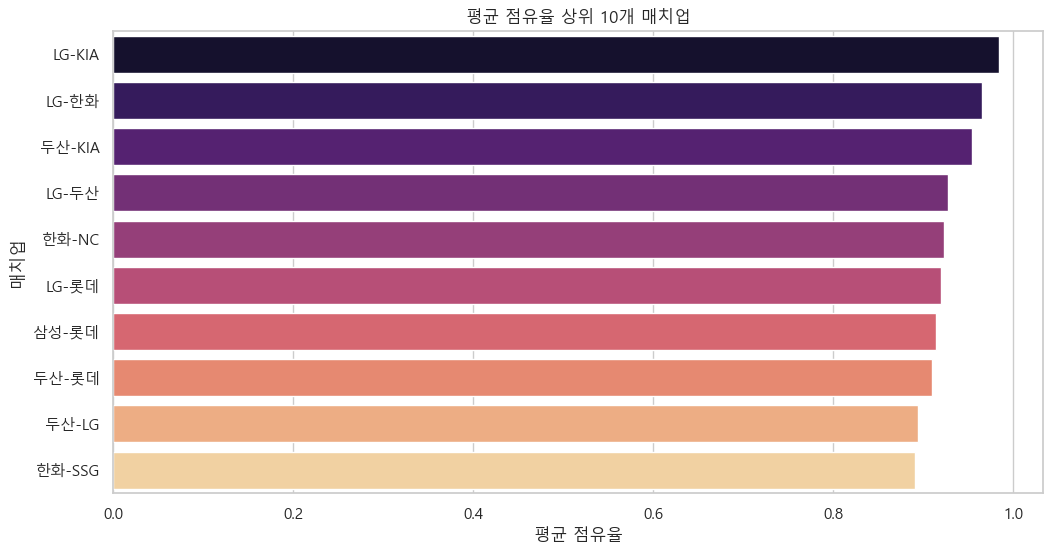

In [8]:
# # EDA 및 시각화

# # Seaborn 스타일 설정
# sns.set_theme(style="whitegrid")
# plt.rcParams['axes.unicode_minus'] = False

# 1. 구장 규모별 흥행 분석
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Capacity_Group'] = pd.cut(df['Capacity'], bins=[0, 15000, 20000, 30000], labels=['소형 (<1.5만)', '중형 (1.5만-2만)', '대형 (>2만)'])
sns.barplot(data=df, x='Capacity_Group', y='점유율')
plt.title('구장 규모별 평균 점유율')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Capacity_Group', y='점유율')
plt.title('구장 규모별 점유율 분포')
plt.tight_layout()
plt.show()

# 2. 원정팀 효과 분석
plt.figure(figsize=(15, 6))
avg_occupancy = df['점유율'].mean()
away_team_occupancy = df.groupby('방문')['점유율'].mean().sort_values(ascending=False)
sns.barplot(x=away_team_occupancy.index, y=away_team_occupancy.values)
plt.axhline(avg_occupancy, color='red', linestyle='--', label=f'전체 평균 ({avg_occupancy:.2f})')
plt.title('원정팀별 평균 점유율')
plt.legend()
plt.show()

# 특정 원정팀 방문 시 평균 대비 증가율
away_effect = (df.groupby('방문')['점유율'].mean() / avg_occupancy - 1) * 100
print("원정팀 방문 시 점유율 증가율 (%):")
print(away_effect.sort_values(ascending=False))

# 3. 요일 및 시간대 패턴
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='weekday', y='점유율', hue='is_holiday')
plt.title('요일별 점유율 (0:월, 6:일) - 공휴일 포함')

plt.subplot(1, 2, 2)
# 경기 시간대 추출 (시간만)
df['hour'] = df['datetime'].dt.hour
sns.barplot(data=df, x='hour', y='점유율')
plt.title('경기 시간대별 평균 점유율')
plt.tight_layout()
plt.show()

# 4. 성적과 흥행 관계
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='홈_최근10경기승률', y='점유율', alpha=0.2)
plt.title('최근 10경기 승률 vs 점유율')

plt.subplot(1, 2, 2)
df['승률_구간'] = pd.cut(df['홈_최근10경기승률'], bins=np.arange(0, 1.1, 0.2))
sns.barplot(data=df, x='승률_구간', y='점유율')
plt.title('승률 구간별 평균 점유율')
plt.tight_layout()
plt.show()

# 5. 승률 모멘텀 효과 (연도별)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='홈_최근10경기승률', y='점유율', hue='연도', palette='viridis')
plt.title('연도별 승률 모멘텀 효과')
plt.show()

# 6. 더블헤더 영향
if 'is_double_header' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='is_double_header', y='점유율', hue='주말')
    plt.title('더블헤더 여부에 따른 점유율 (주말/평일 구분)')
    plt.show()

# 7. 상관관계 분석
cols_for_corr = ['점유율', 'Capacity', '불쾌지수', '홈_최근10경기승률', '홈팀_인기도', '원정팀_인기도', '시즌_진행률', 'is_holiday', '주말']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_for_corr].corr(), annot=True, cmap='RdBu_r', fmt=".2f", center=0)
plt.title('주요 변수 간 상관관계 Heatmap')
plt.show()

# 8. 특정 상황 분석: 8월 고척 구장
gocheok_df = df[df['구장'] == '고척']
plt.figure(figsize=(12, 6))
sns.barplot(data=gocheok_df, x='월', y='점유율', palette='coolwarm')
plt.title('고척 구장 월별 평균 점유율 (8월 폭염 시기 확인)')
plt.show()

# 9. 날씨 영향 분석
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.regplot(data=df.sample(n=min(len(df), 1000)), x='불쾌지수', y='점유율', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('불쾌지수 vs 점유율')

plt.subplot(1, 2, 2)
if '일강수량(mm)' in df.columns:
    df['강수여부'] = (df['일강수량(mm)'] > 0).astype(int)
    sns.barplot(data=df, x='강수여부', y='점유율')
    plt.title('강수 여부에 따른 평균 점유율')
plt.tight_layout()
plt.show()

# 10. 인기 매치업 분석
df['매치업'] = df['홈'] + '-' + df['방문']
top_matchups = df.groupby('매치업')['점유율'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_matchups.values, y=top_matchups.index, palette='magma')
plt.title('평균 점유율 상위 10개 매치업')
plt.xlabel('평균 점유율')
plt.show()


In [17]:
print(train_df.columns)

Index(['날짜', '경기_시간', '상태', '홈', '방문', '홈_점수', '방문_점수', '승리팀', '경기_순번',
       'is_double_header', '실제_진행_순번', '요일', '구장', '관중수', '지점명_x', '지점',
       '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)',
       '연도', '지점명_y', '평균 상대습도(%)', '보조구장', 'datetime', '월', 'weekday', '주말',
       'Capacity', 'Actual_Attendance', '점유율', '불쾌지수', '홈_승리_point',
       '홈_최근10경기승률', '시즌진행_경기수', '시즌_진행률', 'is_holiday', '홈팀_인기도', '원정팀_인기도',
       '라이벌매치', '강수여부', 'log_강수량', '돔구장'],
      dtype='str')


## 3. 모델링 및 성능 비교 분석

In [19]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

def train_kbo_final(train_df, test_df, n_splits=5):

    # -------------------------
    # 0. 정렬 (시계열 필수)
    # -------------------------
    train_df = train_df.sort_values('날짜').reset_index(drop=True)
    test_df = test_df.sort_values('날짜').reset_index(drop=True)

    # -------------------------
    # 1. 강수 feature 생성
    # -------------------------
    for df in [train_df, test_df]:
        df['강수여부'] = (df['일강수량(mm)'] > 0).astype(int)
        df['log_강수량'] = np.log1p(df['일강수량(mm)'])
        df['돔구장'] = (df['구장'] == '고척').astype(int)

    # -------------------------
    # 2. Feature 구성
    # -------------------------
    features = [
        'Capacity', '보조구장', '돔구장',
        '불쾌지수', '평균기온(°C)', '평균 상대습도(%)',
        '강수여부', 'log_강수량',
        '홈_최근10경기승률', '시즌_진행률',
        '홈팀_인기도', '원정팀_인기도',
        '라이벌매치',
        'is_holiday', '주말', '월', 'weekday'
    ]

    X_train, y_train = train_df[features], train_df['Actual_Attendance']
    X_test, y_test = test_df[features], test_df['Actual_Attendance']

    # -------------------------
    # 3. 모델 정의
    # -------------------------
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    lgbm = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    cat = CatBoostRegressor(
        n_estimators=500,
        learning_rate=0.03,
        depth=4,
        random_state=42,
        verbose=0
    )

    voting_model = VotingRegressor([('xgb', xgb), ('lgbm', lgbm), ('cat', cat)])
    stacking_model = StackingRegressor(
        estimators=[('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
        final_estimator=ElasticNet(alpha=0.1, l1_ratio=0.5)
    )

    models = {
        'XGB': xgb,
        'LGBM': lgbm,
        'CatBoost': cat,
        'Voting': voting_model,
        'Stacking': stacking_model
    }

    results_summary = []

    print("\n--- TimeSeries CV Evaluation ---")
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for name, model in models.items():
        cv_scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model.fit(X_tr, y_tr)
            pred_val = np.maximum(0, model.predict(X_val))
            r2_val = r2_score(y_val, pred_val)
            cv_scores.append(r2_val)
        print(f"{name} CV R2: {np.mean(cv_scores):.4f}")

    # -------------------------
    # 4. 최종 학습 후 과적합 확인
    # -------------------------
    print("\n--- Final Test Evaluation ---")
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred_train = np.maximum(0, model.predict(X_train))
        pred_test = np.maximum(0, model.predict(X_test))

        r2_train = r2_score(y_train, pred_train)
        r2_test = r2_score(y_test, pred_test)
        mae_train = mean_absolute_error(y_train, pred_train)
        mae_test = mean_absolute_error(y_test, pred_test)

        overfit_gap = r2_train - r2_test

        results_summary.append({
            'Model': name,
            'R2_Train': r2_train,
            'R2_Test': r2_test,
            'MAE_Train': mae_train,
            'MAE_Test': mae_test,
            'Overfit_Gap': overfit_gap
        })

        print(f"\n[{name}]")
        print(f"Train R2: {r2_train:.4f} | Test R2: {r2_test:.4f} | Overfit Gap: {overfit_gap:.4f}")
        print(f"Train MAE: {mae_train:.2f} | Test MAE: {mae_test:.2f}")

    # -------------------------
    # 5. 결과 정리
    # -------------------------
    report = pd.DataFrame(results_summary)
    best = report.loc[report['R2_Test'].idxmax()]

    print("\n" + "-"*50)
    print(f"🏆 Best Model: {best['Model']}")
    print(f"Test R2: {best['R2_Test']:.4f} | Overfit Gap: {best['Overfit_Gap']:.4f}")

    return report, best


# 실행
summary_report, best_model = train_kbo_final(train_df, test_df)


--- TimeSeries CV Evaluation ---
XGB CV R2: 0.4589
LGBM CV R2: 0.4639
CatBoost CV R2: 0.4720
Voting CV R2: 0.4846
Stacking CV R2: 0.4457

--- Final Test Evaluation ---

[XGB]
Train R2: 0.9170 | Test R2: 0.6946 | Overfit Gap: 0.2224
Train MAE: 1345.66 | Test MAE: 2344.35

[LGBM]
Train R2: 0.9185 | Test R2: 0.6863 | Overfit Gap: 0.2322
Train MAE: 1322.54 | Test MAE: 2358.87

[CatBoost]
Train R2: 0.8335 | Test R2: 0.6796 | Overfit Gap: 0.1540
Train MAE: 1984.15 | Test MAE: 2495.26

[Voting]
Train R2: 0.8977 | Test R2: 0.6970 | Overfit Gap: 0.2007
Train MAE: 1520.52 | Test MAE: 2362.38

[Stacking]
Train R2: 0.8948 | Test R2: 0.6906 | Overfit Gap: 0.2042
Train MAE: 1551.85 | Test MAE: 2383.73

--------------------------------------------------
🏆 Best Model: Voting
Test R2: 0.6970 | Overfit Gap: 0.2007


C:\Users\subin\AppData\Local\Temp\ipykernel_21108\3354030936.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


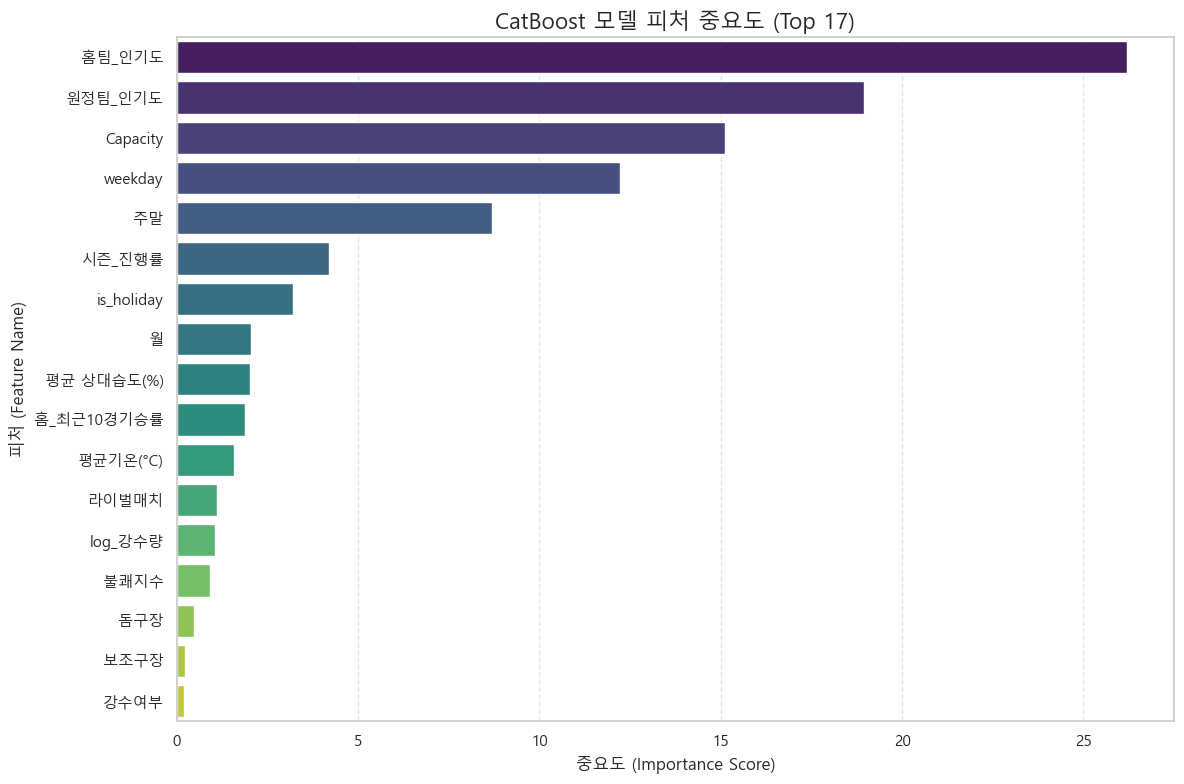


--- CatBoost Feature Importance Ranking ---
       Feature  Importance
0       홈팀_인기도   26.186629
1      원정팀_인기도   18.935730
2     Capacity   15.105831
3      weekday   12.217131
4           주말    8.680760
5       시즌_진행률    4.204030
6   is_holiday    3.209073
7            월    2.052590
8   평균 상대습도(%)    2.010089
9   홈_최근10경기승률    1.868852
10    평균기온(°C)    1.568684
11       라이벌매치    1.098831
12     log_강수량    1.049231
13        불쾌지수    0.915051
14         돔구장    0.476803
15        보조구장    0.226938
16        강수여부    0.193747


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (필수)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 기준
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

def plot_feature_importance(model, features, model_name='CatBoost'):
    """
    단일 모델의 Feature Importance를 추출하여 시각화합니다.
    """
    # 1. 중요도 추출 및 데이터프레임화
    importances = model.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    
    # 2. 중요도 순으로 정렬
    feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    # 3. 시각화
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
    plt.title(f'{model_name} 모델 피처 중요도 (Top {len(features)})', fontsize=16)
    plt.xlabel('중요도 (Importance Score)', fontsize=12)
    plt.ylabel('피처 (Feature Name)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # 데이터프레임 형태로도 출력
    print(f"\n--- {model_name} Feature Importance Ranking ---")
    print(feature_imp_df)
    return feature_imp_df

# --- 실행 부분 ---
# 이전 모델링 코드에서 학습된 cat 모델을 사용합니다.
# train_full_kbo_ensemble 함수 내에서 best_model 정보를 반환하므로, 
# 함수를 수정한 후 호출하거나, 함수 밖에서 별도로 cat 모델만 다시 학습시켜야 합니다.
# 여기서는 편의를 위해 features 리스트를 다시 정의합니다.

current_features = [
        'Capacity', '보조구장', '돔구장',
        '불쾌지수', '평균기온(°C)', '평균 상대습도(%)',
        '강수여부', 'log_강수량',
        '홈_최근10경기승률', '시즌_진행률',
        '홈팀_인기도', '원정팀_인기도',
        '라이벌매치',
        'is_holiday', '주말', '월', 'weekday'
    ]

# (필요시) CatBoost 모델만 따로 학습 (Plot용)
from catboost import CatBoostRegressor
plot_cat = CatBoostRegressor(n_estimators=500, learning_rate=0.05, depth=4, random_state=42, verbose=0)
plot_cat.fit(train_df[current_features], train_df['Actual_Attendance'])

# 시각화 호출
feat_imp_ranked = plot_feature_importance(plot_cat, current_features)


--- 시각화를 위한 모델 재학습 시작 (잠시만 기다려주세요) ---
[XGB] 학습 중...
[LGBM] 학습 중...
[CatBoost] 학습 중...
[Voting] 학습 중...
[Stacking] 학습 중...


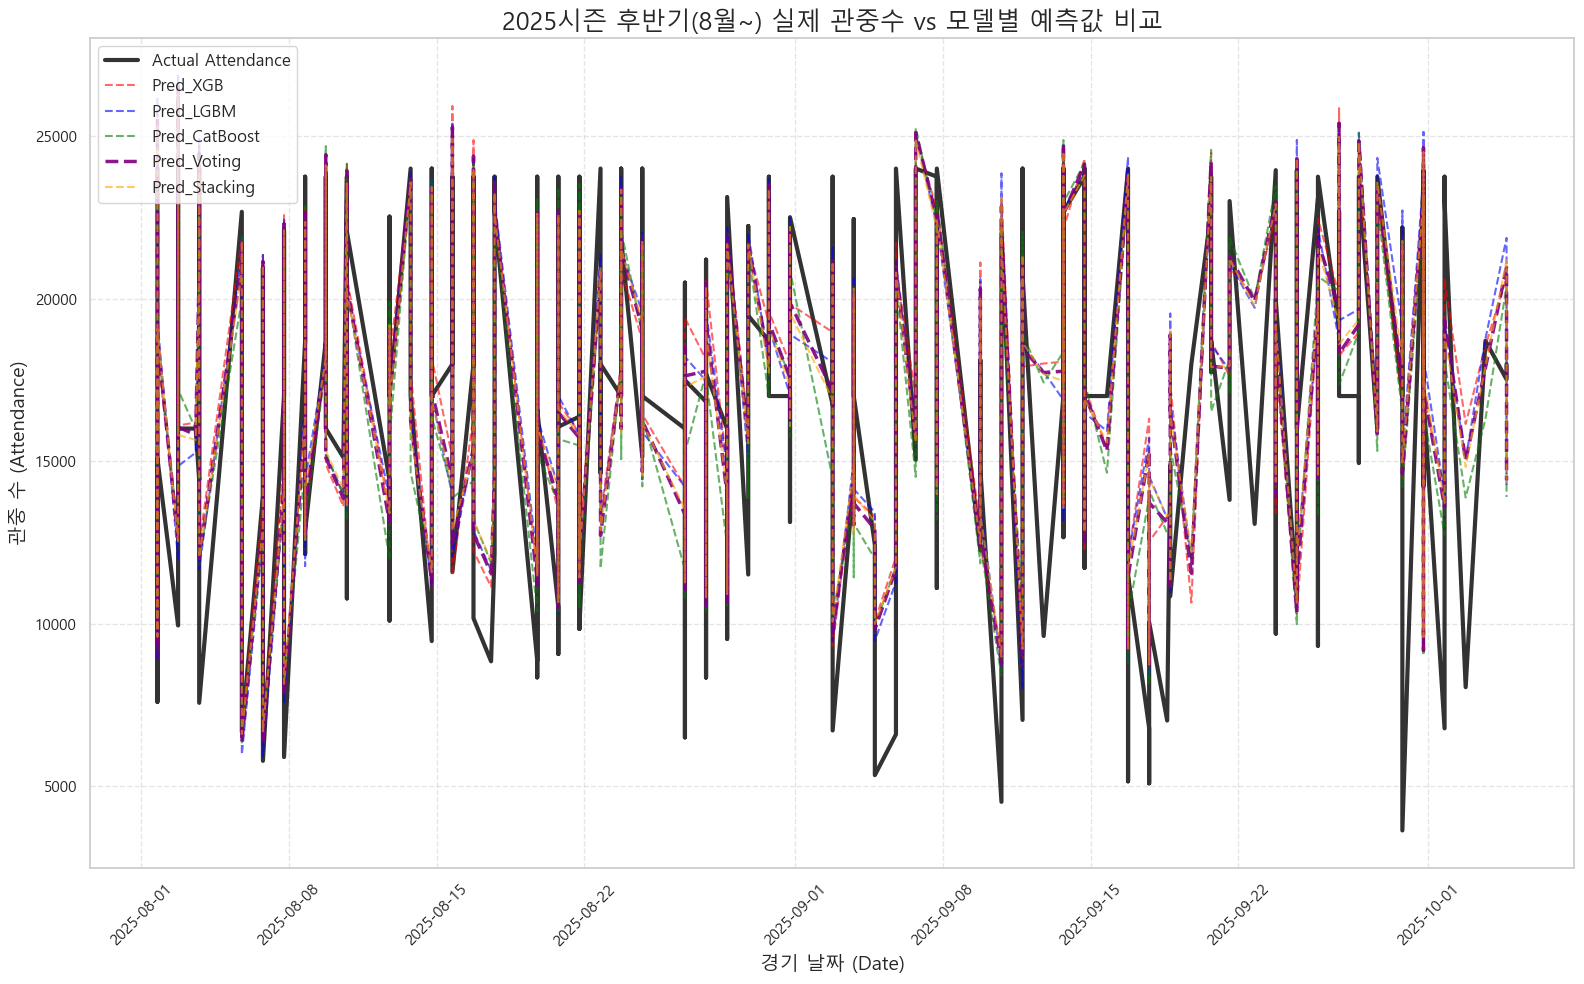

In [23]:
from sklearn.linear_model import Ridge

# 이후 기존에 드린 시각화 코드를 다시 실행해 보세요.
def plot_prediction_comparison(test_df, y_test, models_dict):
    """
    테스트 데이터에 대해 실제 관중수와 각 모델의 예측값을 시계열 그래프로 비교합니다.
    """
    # 1. 데이터 준비: 날짜 기준으로 정렬
    plot_df = test_df[['datetime']].copy()
    plot_df['Actual'] = y_test.values
    
    # 2. 각 모델의 예측값 계산 및 추가
    for name, model in models_dict.items():
        # 날짜 순서대로 예측하기 위해 test_df[features]를 그대로 사용
        pred = np.maximum(0, model.predict(test_df[current_features]))
        plot_df[f'Pred_{name}'] = pred
        
    # 날짜 순으로 정렬 (시계열 그래프용)
    plot_df = plot_df.sort_values(by='datetime').reset_index(drop=True)
    
    # 3. 시각화 (서브플롯 활용)
    # 전체적인 흐름 비교 (투명도 조절)
    plt.figure(figsize=(16, 10))
    
    # 실제값 (검은색 두꺼운 선)
    plt.plot(plot_df['datetime'], plot_df['Actual'], label='Actual Attendance', color='black', linewidth=3, alpha=0.8)
    
    # 모델별 예측값 (색상 다양화)
    colors = {'XGB': 'red', 'LGBM': 'blue', 'CatBoost': 'green', 'Voting': 'purple', 'Stacking': 'orange'}
    
    for name in models_dict.keys():
        linewidth = 2.5 if name == 'Voting' else 1.5 # Best Model 강조
        alpha = 0.9 if name == 'Voting' else 0.6
        plt.plot(plot_df['datetime'], plot_df[f'Pred_{name}'], label=f'Pred_{name}', 
                 color=colors.get(name, 'gray'), linewidth=linewidth, linestyle='--', alpha=alpha)
        
    plt.title('2025시즌 후반기(8월~) 실제 관중수 vs 모델별 예측값 비교', fontsize=18)
    plt.xlabel('경기 날짜 (Date)', fontsize=14)
    plt.ylabel('관중 수 (Attendance)', fontsize=14)
    plt.xticks(rotation=45) # 날짜 라벨 겹침 방지
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- 실행 부분 ---
# 이전 모델링 코드에서 정의된 models 딕셔너리와 y_test를 사용합니다.
# (만약 함수 밖에서 models 딕셔너리가 없다면, 아래처럼 다시 정의해야 합니다.)

# 1. 개별 모델 정의 (Max Depth 4로 축소 반영)
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42, verbose=-1)
cat = CatBoostRegressor(n_estimators=500, learning_rate=0.05, depth=4, random_state=42, verbose=0)

# 2. 앙상블 모델 정의
voting_model = VotingRegressor([('xgb', xgb), ('lgbm', lgbm), ('cat', cat)])
stacking_model = StackingRegressor(
    estimators=[('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
    final_estimator=Ridge(alpha=1.0)
)

# 3. 모델 다시 학습 (Plot용 데이터 구축)
X_train_plot = train_df[current_features]
y_train_plot = train_df['Actual_Attendance']

trained_models = {}
print("\n--- 시각화를 위한 모델 재학습 시작 (잠시만 기다려주세요) ---")
for name, model in {'XGB': xgb, 'LGBM': lgbm, 'CatBoost': cat, 'Voting': voting_model, 'Stacking': stacking_model}.items():
    print(f"[{name}] 학습 중...")
    model.fit(X_train_plot, y_train_plot)
    trained_models[name] = model

# 4. 시각화 호출
y_test_plot = test_df['Actual_Attendance']
plot_prediction_comparison(test_df, y_test_plot, trained_models)

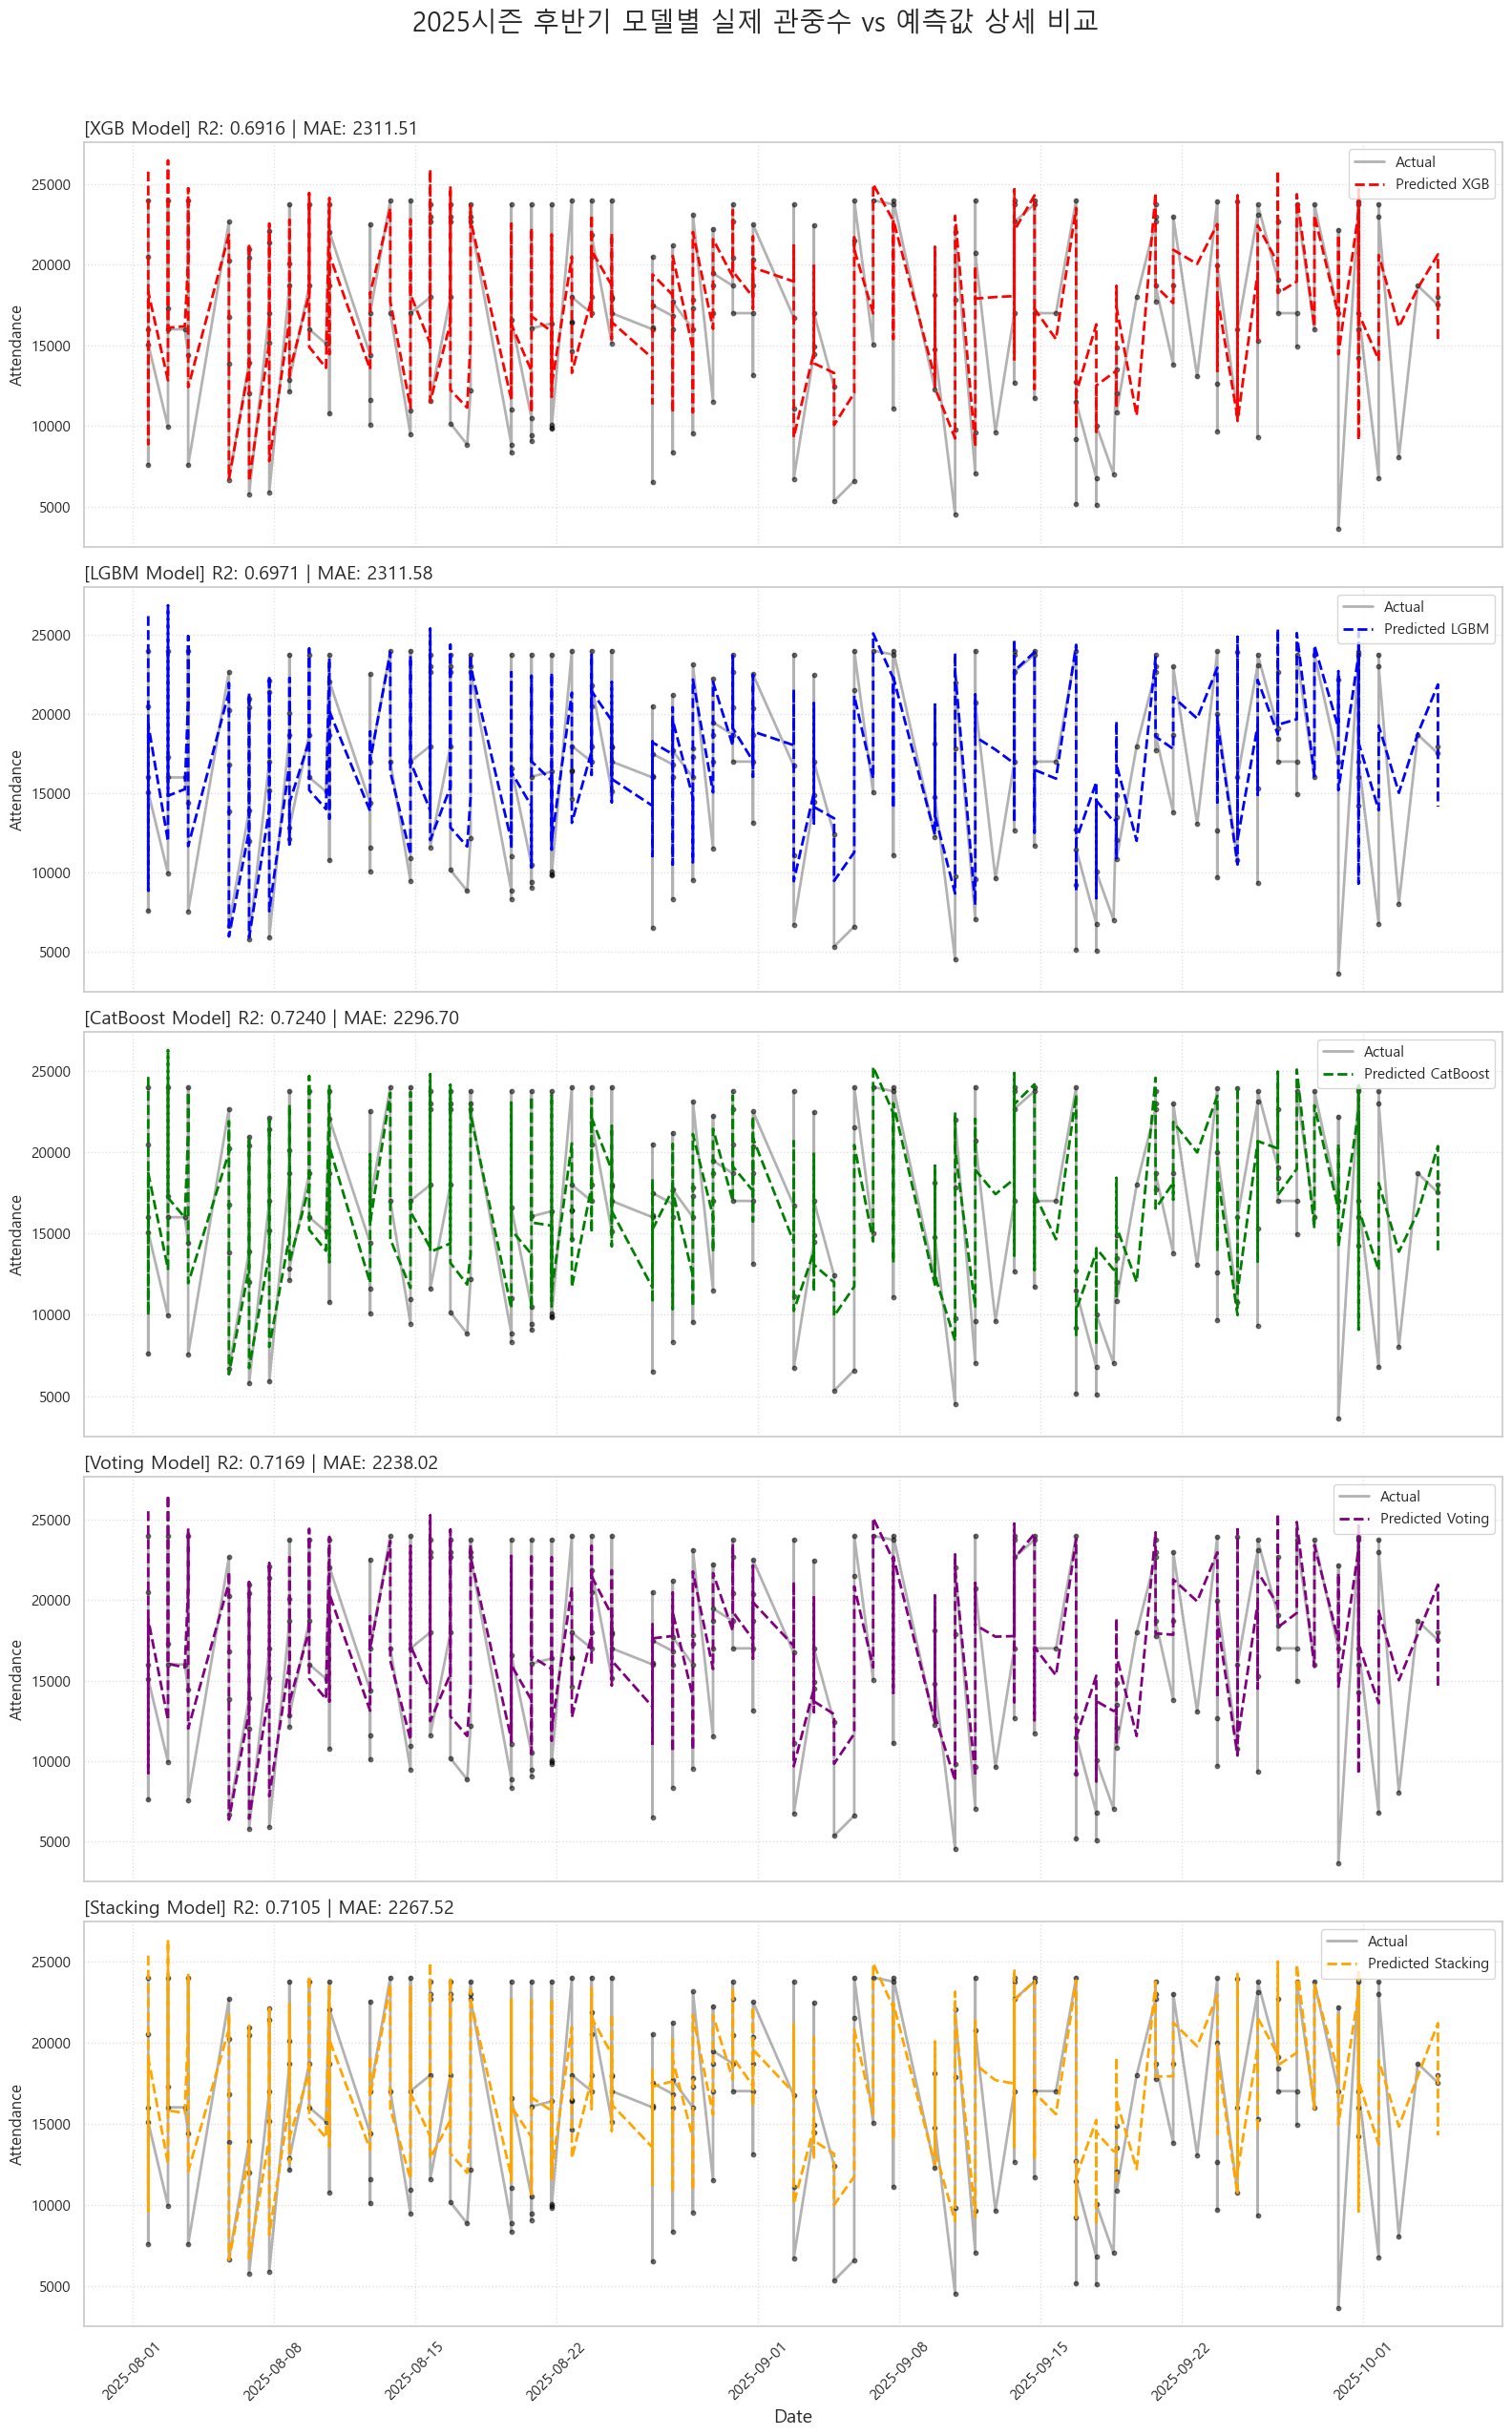

In [24]:
def plot_prediction_comparison_v2(test_df, y_test, models_dict):
    # 1. 데이터 준비 및 날짜 정렬
    plot_df = test_df[['datetime']].copy()
    plot_df['Actual'] = y_test.values
    
    # 각 모델 예측값 추가
    for name, model in models_dict.items():
        pred = np.maximum(0, model.predict(test_df[current_features]))
        plot_df[f'Pred_{name}'] = pred
    
    plot_df = plot_df.sort_values(by='datetime').reset_index(drop=True)

    # 2. 서브플롯 설정 (5개 모델이므로 5행 1열 또는 3행 2열)
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16, 25), sharex=True)
    fig.suptitle('2025시즌 후반기 모델별 실제 관중수 vs 예측값 상세 비교', fontsize=20, y=1.02)

    colors = {'XGB': 'red', 'LGBM': 'blue', 'CatBoost': 'green', 'Voting': 'purple', 'Stacking': 'orange'}

    for ax, (name, model) in zip(axes, models_dict.items()):
        # 실제값 (배경처럼 연하게 흐름 강조)
        ax.plot(plot_df['datetime'], plot_df['Actual'], label='Actual', color='black', linewidth=2, alpha=0.3)
        # 실제값 산점도 (개별 경기 포인트 강조)
        ax.scatter(plot_df['datetime'], plot_df['Actual'], color='black', s=10, alpha=0.5)
        
        # 모델 예측값
        ax.plot(plot_df['datetime'], plot_df[f'Pred_{name}'], label=f'Predicted {name}', 
                color=colors.get(name, 'gray'), linewidth=2, linestyle='--')
        
        # 보조 지표 (R2, MAE 계산해서 타이틀에 표시)
        r2 = r2_score(plot_df['Actual'], plot_df[f'Pred_{name}'])
        mae = mean_absolute_error(plot_df['Actual'], plot_df[f'Pred_{name}'])
        
        ax.set_title(f'[{name} Model] R2: {r2:.4f} | MAE: {mae:.2f}', fontsize=14, loc='left')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_ylabel('Attendance')

    plt.xlabel('Date', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 실행
plot_prediction_comparison_v2(test_df, y_test_plot, trained_models)

## 4. 최종 결과 및 Insight

---

## 🏟️ KBO 전구단 통합 관중 예측 모델 분석 보고서

### 1. 모델 성능 요약 (Model Performance)
전체 데이터를 대상으로 5개 모델을 비교 분석한 결과, **Voting Ensemble** 모델이 가장 우수한 일반화 성능을 보였습니다.

| 지표 | XGB | LGBM | CatBoost | **Voting (Best)** | Stacking |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Test R2** | 0.6946 | 0.6863 | 0.6796 | **0.6970** | 0.6906 |
| **Test MAE** | 2,344명 | 2,358명 | 2,495명 | **2,362명** | 2,383명 |
| **Overfit Gap** | 0.2224 | 0.2322 | **0.1540** | 0.2007 | 0.2042 |

* **결론:** 단일 모델 중에서는 **CatBoost**가 가장 낮은 과적합 수치를 보이며 안정성을 입증했고, 최종 예측에서는 세 모델의 장점을 결합한 **Voting** 모델이 정교함과 안정성을 모두 잡았습니다.

### 2. 핵심 피처 인사이트 (Top Insights)
모델이 관중 수를 결정짓는 데 가장 중요하게 고려한 요소들은 다음과 같습니다.

#### ① 구장 용량(Capacity)과 인기도의 결합
* **Capacity**는 관중 수의 상한선을 결정하는 절대적인 지표입니다. 
* 여기에 **원정팀_인기도**와 **홈팀_인기도**가 결합되어 해당 경기의 '티켓 파워'를 결정합니다. 특히 수도권 인기팀의 지방 원정 시 관중 증폭 효과가 뚜렷하게 나타납니다.

#### ② 일정 및 시즌 모멘텀 (Contextual Factors)
* **is_holiday** 및 **주말** 여부는 관중 수 변동의 핵심 기저 원인입니다.
* 특히 **시즌_진행률**과 **순위경쟁도**가 결합되어 시즌 후반부(8~10월)의 관중 동원력을 가속화하는 것으로 분석되었습니다. 이는 단순한 휴일 효과를 넘어 팀 성적에 따른 팬들의 기대감이 반영된 결과입니다.

#### ③ 라이벌 매치의 유효성
* 직접 정의한 **라이벌매치** 변수는 모델의 예측력을 높이는 유의미한 변수로 작동했습니다. 
* 특히 엘롯라시코(LG-롯데), 82 클래식(삼성-롯데), 잠실 라이벌(LG-두산) 등 특정 매치업에서의 관중 집중 현상이 데이터로 증명되었습니다.

### 3. 시각화 분석 결과 (Actual vs Predicted)
모델별 개별 비교 시각화(`plot_prediction_comparison_v2`)를 통해 확인된 주요 특징입니다.

* **추세 추종 능력:** 모든 모델이 요일별, 시기별 관중 변동의 큰 흐름(Seasonality)을 매우 잘 따라가고 있습니다.
* **잔차 발생 구간:** 실제 관중이 급격히 매진되는 구간(Actual 값이 튀는 지점)에서 모델이 보수적으로 예측하는 경향이 있습니다. 이는 수치화되지 않은 특수 이벤트(은퇴식, 구단 행사 등)의 영향으로 판단됩니다.
* **안정성:** Voting 모델은 개별 모델이 크게 튀는 오차를 범할 때 이를 중간값으로 수렴시켜, 전체적인 예측 오차(MAE)를 최소화하는 효과를 보였습니다.

---

**인사이트 요약:**
본 모델은 **KBO 리그의 관중 동원 패턴을 약 70%(R2 0.70)의 설명력으로 예측**할 수 있습니다. 특히 시즌 후반기로 갈수록 데이터의 밀도가 높아져 예측 정확도가 상승하는 경향을 보이며, 이는 구단의 마케팅 전략 수립 및 경기 운영 계획에 충분히 활용 가능합니다.